In [ ]:
import pandas as pd

In [ ]:
df_with_geo = pd.read_csv('schools_filtered_with_loc.csv')

In [ ]:
df_with_geo


In [ ]:
df_origin = pd.read_csv('data/schools_filtered_2.csv')

In [ ]:
df_origin

In [ ]:
df_overall = pd.merge(df_origin, df_with_geo, left_on='login', right_on='Логин ОО', how='inner')

In [ ]:
df_overall.drop(columns=['Логин ОО', 'Адрес', 'addr_clean']).to_csv('data/schools_filtered_2_with_loc.csv', index=False)

In [ ]:
df = pd.read_csv('data/schools_filtered_2_with_loc.csv')

In [ ]:
df

## 1. Расстояние (км) до административного центра субъекта РФ

In [ ]:
import pandas as pd
import numpy as np


def haversine_vectorized(lat1, lon1, lat2, lon2):
    R = 6371.0088  # Радиус Земли в км (WGS84)
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat / 2.0)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2.0)**2
    return 2 * R * np.arctan2(np.sqrt(a), np.sqrt(1 - a))


REGION_CENTERS = [
    ("Адыгея", 44.6098, 40.1007), ("Алтай", 51.7136, 94.5045), ("Алтайский край", 53.3548, 83.7698),
    ("Амурская область", 50.2747, 127.5413), ("Архангельская область", 64.5401, 40.5433),
    ("Астраханская область", 46.3479, 48.0336), ("Башкортостан", 54.7388, 55.9721),
    ("Белгородская область", 50.5957, 36.5871), ("Брянская область", 53.2434, 34.3656),
    ("Бурятия", 51.8272, 107.6064), ("Владимирская область", 56.1290, 40.4066),
    ("Волгоградская область", 48.7071, 44.5169), ("Вологодская область", 59.2181, 39.8969),
    ("Воронежская область", 51.6683, 39.1840), ("Дагестан", 42.9849, 47.5047),
    ("Еврейская АО", 48.7951, 132.9255), ("Забайкальский край", 51.8266, 110.7555),
    ("Ивановская область", 56.9968, 40.9819), ("Ингушетия", 43.1725, 44.8104),
    ("Иркутская область", 52.2870, 104.3050), ("Кабардино-Балкария", 43.4855, 43.6111),
    ("Калининградская область", 54.7065, 20.5080), ("Калмыкия", 46.3119, 44.2629),
    ("Калужская область", 54.5141, 36.2617), ("Камчатский край", 53.0442, 158.6503),
    ("Карачаево-Черкесия", 43.8956, 41.9217), ("Карелия", 61.7891, 34.3469),
    ("Кемеровская область", 55.3617, 86.0857), ("Кировская область", 58.6035, 49.6680),
    ("Коми", 67.5527, 53.7946), ("Костромская область", 57.7665, 40.9272),
    ("Краснодарский край", 45.0355, 38.9753), ("Красноярский край", 56.0097, 92.8518),
    ("Крым", 44.9521, 34.1024), ("Курганская область", 55.4470, 65.3437),
    ("Курская область", 51.7374, 36.1926), ("Ленинградская область", 59.9343, 30.3351),
    ("Липецкая область", 52.6060, 39.5949), ("Магаданская область", 59.5687, 150.8042),
    ("Марий Эл", 56.6347, 47.8918), ("Мордовия", 54.1862, 45.1750),
    ("Москва", 55.7558, 37.6173), ("Московская область", 55.5810, 37.3920),
    ("Мурманская область", 68.9585, 33.0827), ("Ненецкий АО", 67.6378, 53.0069),
    ("Нижегородская область", 56.3286, 44.0022), ("Новгородская область", 58.5218, 31.2716),
    ("Новосибирская область", 55.0084, 82.9357), ("Омская область", 54.9885, 73.3680),
    ("Оренбургская область", 51.7727, 55.1006), ("Орловская область", 52.9679, 36.0702),
    ("Пензенская область", 53.1951, 45.0186), ("Пермский край", 58.0000, 56.2500),
    ("Приморский край", 43.1198, 131.8869), ("Псковская область", 57.8136, 28.3496),
    ("Ростовская область", 47.2313, 39.7233), ("Рязанская область", 54.6295, 39.7425),
    ("Самарская область", 53.1951, 50.1154), ("Санкт-Петербург", 59.9343, 30.3351),
    ("Саратовская область", 51.5336, 46.0344), ("Саха (Якутия)", 62.0280, 129.7326),
    ("Сахалинская область", 46.9586, 142.7384), ("Свердловская область", 56.8389, 60.6057),
    ("Севастополь", 44.5883, 33.5320), ("Северная Осетия", 43.0205, 44.6687),
    ("Смоленская область", 54.7826, 32.0452), ("Ставропольский край", 45.0445, 41.9691),
    ("Тамбовская область", 52.7216, 41.4528), ("Татарстан", 55.7963, 49.1088),
    ("Тверская область", 56.8587, 35.9176), ("Томская область", 56.4977, 84.9743),
    ("Тульская область", 54.1931, 37.6182), ("Тыва", 51.7197, 94.4535),
    ("Тюменская область", 57.1553, 65.5622), ("Удмуртия", 56.8523, 53.2130),
    ("Ульяновская область", 54.3193, 48.3922), ("Хабаровский край", 48.4827, 135.0847),
    ("Хакасия", 53.7227, 89.4722), ("Ханты-Мансийский АО", 61.0043, 69.0021),
    ("Челябинская область", 55.1543, 61.4297), ("Чечня", 43.3187, 45.6932),
    ("Чувашия", 56.1439, 47.2502), ("Чукотский АО", 64.5717, 177.5707),
    ("Ямало-Ненецкий АО", 66.6253, 66.6307), ("Ярославская область", 57.6261, 39.8845)
]

regions_df = pd.DataFrame(REGION_CENTERS, columns=["region_name", "reg_lat", "reg_lon"])


df = pd.read_csv("data/schools_filtered_2_with_loc.csv", dtype={"lat": float, "lon": float})
df = df.dropna(subset=["lat", "lon"])  # Исключаем строки без координат

school_lat = df["lat"].values
school_lon = df["lon"].values

dist_matrix = haversine_vectorized(
    school_lat[:, np.newaxis], school_lon[:, np.newaxis],
    regions_df["reg_lat"].values[np.newaxis, :],
    regions_df["reg_lon"].values[np.newaxis, :]
)

nearest_idx = np.argmin(dist_matrix, axis=1)

df["distance_to_regional_center"] = dist_matrix[np.arange(len(df)), nearest_idx]
df["nearest_region_center"] = regions_df["region_name"].values[nearest_idx]

df.to_csv("data_extended/1.csv", index=False, encoding="utf-8-sig")

## 2. Расстояние до ближайшего города с населением 100 000+

In [ ]:
import pandas as pd
import numpy as np


def haversine_vectorized(lat1, lon1, lat2, lon2):
    R = 6371.0088
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat / 2.0)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2.0)**2
    return 2 * R * np.arctan2(np.sqrt(a), np.sqrt(1 - a))


LARGE_CITIES = [
    ("Москва", 55.7558, 37.6173), ("Санкт-Петербург", 59.9343, 30.3351),
    ("Новосибирск", 55.0084, 82.9357), ("Екатеринбург", 56.8389, 60.6057),
    ("Казань", 55.7887, 49.1221), ("Нижний Новгород", 56.3286, 44.0022),
    ("Челябинск", 55.1543, 61.4297), ("Красноярск", 56.0097, 92.8518),
    ("Самара", 53.1951, 50.1154), ("Уфа", 54.7388, 55.9721),
    ("Ростов-на-Дону", 47.2313, 39.7233), ("Омск", 54.9885, 73.3680),
    ("Краснодар", 45.0355, 38.9753), ("Воронеж", 51.6683, 39.1840),
    ("Пермь", 58.0104, 56.2294), ("Волгоград", 48.7071, 44.5169),
    ("Саратов", 51.5336, 46.0344), ("Тюмень", 57.1553, 65.5622),
    ("Тольятти", 53.5303, 49.3461), ("Ижевск", 56.8523, 53.2130),
    ("Барнаул", 53.3548, 83.7698), ("Ульяновск", 54.3193, 48.3922),
    ("Иркутск", 52.2870, 104.3050), ("Хабаровск", 48.4827, 135.0847),
    ("Ярославль", 57.6261, 39.8845), ("Владивосток", 43.1198, 131.8869),
    ("Махачкала", 42.9849, 47.5047), ("Томск", 56.4977, 84.9743),
    ("Оренбург", 51.7727, 55.1006), ("Кемерово", 55.3617, 86.0857),
    ("Новокузнецк", 53.7596, 87.1216), ("Рязань", 54.6295, 39.7425),
    ("Астрахань", 46.3479, 48.0336), ("Калининград", 54.7065, 20.5080),
    ("Пенза", 53.1951, 45.0186), ("Липецк", 52.6060, 39.5949),
    ("Тула", 54.1931, 37.6182), ("Киров", 58.6035, 49.6680),
    ("Чебоксары", 56.1439, 47.2502), ("Курск", 51.7374, 36.1926),
    ("Ставрополь", 45.0445, 41.9691), ("Улан-Удэ", 51.8272, 107.6064),
    ("Тверь", 56.8587, 35.9176), ("Магнитогорск", 53.3900, 58.9800),
    ("Иваново", 56.9968, 40.9819), ("Брянск", 53.2434, 34.3656),
    ("Сочи", 43.5855, 39.7231), ("Белгород", 50.5957, 36.5871),
    ("Владимир", 56.1290, 40.4066), ("Сургут", 61.2500, 73.4167),
    ("Нижний Тагил", 57.9197, 59.9650), ("Архангельск", 64.5401, 40.5433),
    ("Калуга", 54.5141, 36.2617), ("Смоленск", 54.7826, 32.0452),
    ("Курган", 55.4470, 65.3437), ("Орёл", 52.9679, 36.0702),
    ("Череповец", 59.1374, 37.9092), ("Вологда", 59.2181, 39.8969),
    ("Саранск", 54.1862, 45.1750), ("Тамбов", 52.7216, 41.4528),
    ("Мурманск", 68.9585, 33.0827), ("Якутск", 62.0280, 129.7326),
    ("Грозный", 43.3187, 45.6932), ("Нальчик", 43.4855, 43.6111),
    ("Братск", 56.1410, 101.6200), ("Новороссийск", 44.7230, 37.7710),
    ("Дзержинск", 56.2380, 43.4610), ("Псков", 57.8136, 28.3496),
    ("Ангарск", 52.5410, 103.8890), ("Балашиха", 55.8090, 37.9580),
    ("Южно-Сахалинск", 46.9586, 142.7384), ("Сыктывкар", 61.6681, 50.8356),
    ("Нижневартовск", 60.9340, 76.5700), ("Набережные Челны", 55.7440, 52.4060),
    ("Бийск", 52.5390, 85.2080), ("Прокопьевск", 53.8760, 86.7220),
    ("Энгельс", 51.4840, 46.1170), ("Благовещенск", 50.2747, 127.5413),
    ("Старый Оскол", 51.2960, 37.8360), ("Великий Новгород", 58.5218, 31.2716),
    ("Норильск", 69.3390, 88.2270), ("Альметьевск", 54.9030, 52.3050),
    ("Люберцы", 55.6770, 37.8940), ("Королёв", 55.9170, 37.8260),
    ("Мытищи", 55.9110, 37.7300), ("Балаково", 52.0380, 47.7820),
    ("Арзамас", 55.3940, 43.8380), ("Серпухов", 54.9160, 37.4110),
    ("Орск", 51.2110, 58.5480), ("Новокуйбышевск", 53.1050, 49.8360),
    ("Каспийск", 42.8870, 47.6430), ("Химки", 55.8970, 37.4480),
    ("Миасс", 55.0450, 60.1060), ("Георгиевск", 44.1380, 43.4780),
    ("Подольск", 55.4310, 37.5440), ("Ковров", 56.3600, 41.3190),
    ("Елец", 52.6170, 38.4920), ("Невинномысск", 44.6330, 41.9380),
    ("Димитровград", 54.2170, 49.6190), ("Стерлитамак", 53.6280, 55.9380),
    ("Копейск", 55.1160, 61.6200), ("Пятигорск", 44.0490, 43.0680),
    ("Кисловодск", 43.9130, 42.7200), ("Обнинск", 55.0970, 36.6170),
    ("Нефтекамск", 56.0910, 54.2570), ("Салават", 53.3590, 55.9350),
    ("Ноябрьск", 63.1890, 75.4720), ("Абакан", 53.7227, 89.4722),
    ("Новочебоксарск", 56.1070, 47.4930), ("Хасавюрт", 43.2510, 46.5790),
    ("Березники", 59.4100, 56.8200), ("Щёлково", 55.9210, 37.9780),
    ("Красногорск", 55.8320, 37.3280), ("Долгопрудный", 55.9380, 37.5130),
    ("Реутов", 55.7660, 37.8620), ("Пушкино", 56.0120, 37.8540),
    ("Жуковский", 55.5950, 38.1200), ("Раменское", 55.5680, 38.2290),
    ("Одинцово", 55.6790, 37.2810), ("Сергиев Посад", 56.4680, 38.3220),
    ("Электросталь", 55.7890, 38.4450), ("Колпино", 59.7430, 30.5960),
    ("Кронштадт", 59.9930, 29.7680), ("Ленинградская обл.", 59.9343, 30.3351) # fallback
]

cities_df = pd.DataFrame(LARGE_CITIES, columns=["city", "lat", "lon"])

df = pd.read_csv("data_extended/1.csv", dtype={"lat": float, "lon": float})
df = df.dropna(subset=["lat", "lon"])

school_lat = df["lat"].values
school_lon = df["lon"].values

dist_matrix = haversine_vectorized(
    school_lat[:, np.newaxis], school_lon[:, np.newaxis],
    cities_df["lat"].values[np.newaxis, :],
    cities_df["lon"].values[np.newaxis, :]
)

nearest_idx = np.argmin(dist_matrix, axis=1)

df["distance_to_large_city"] = dist_matrix[np.arange(len(df)), nearest_idx]
df["nearest_large_city"] = cities_df["city"].values[nearest_idx]

bins = [0, 5, 15, 30, 60, np.inf]
labels = ["в_городе", "ближний_пригород", "спальный_пояс", "периферия", "удалённая_зона"]
df["distance_to_large_city_cat"] = pd.cut(
    df["distance_to_large_city"], bins=bins, labels=labels, right=False
)

df.to_csv("data_extended/2.csv", index=False, encoding="utf-8-sig")

## 3. Расстояние до ближайшей федеральной или региональной трассы

In [ ]:
import pandas as pd
import numpy as np
import os
from pyrosm import OSM
import gc

i = 3
input_file = f"data_extended/{i-1}.csv"
output_file = f"data_extended/{i}.csv"
roads_pbf = "additional_data/roads_filtered.osm.pbf"

if not os.path.exists(input_file):
    raise FileNotFoundError(f"Файл {input_file} не найден.")
if not os.path.exists(roads_pbf):
    raise FileNotFoundError(f"Файл {roads_pbf} не найден.")

def haversine_vec(lat1, lon1, lat2, lon2):
    R = 6371.0088
    dlat = np.radians(lat2 - lat1)
    dlon = np.radians(lon2 - lon1)
    a = np.sin(dlat/2.0)**2 + np.cos(np.radians(lat1)) * np.cos(np.radians(lat2)) * np.sin(dlon/2.0)**2
    return 2 * R * np.arctan2(np.sqrt(a), np.sqrt(1 - a))

df = pd.read_csv(input_file, dtype={"lat": float, "lon": float})
df = df.dropna(subset=["lat", "lon"]).copy()
s_lat = df["lat"].values
s_lon = df["lon"].values
n_schools = len(df)

osm = OSM(roads_pbf)
roads = osm.get_network(network_type="driving")

coords = roads.explode(ignore_index=True).get_coordinates()
r_lat = coords["y"].values
r_lon = coords["x"].values
n_roads = len(r_lat)

min_dists = np.full(n_schools, np.inf, dtype=np.float32)

chunk_s = 100          # Чанк школ
chunk_r = 200_000      # Чанк дорог (ограничивает матрицу ~160 МБ)

for idx_s in range(0, n_schools, chunk_s):
    end_s = min(idx_s + chunk_s, n_schools)
    slat = s_lat[idx_s:end_s]
    slon = s_lon[idx_s:end_s]

    best_chunk = np.full(len(slat), np.inf, dtype=np.float32)

    for idx_r in range(0, n_roads, chunk_r):
        end_r = min(idx_r + chunk_r, n_roads)
        rlat = r_lat[idx_r:end_r]
        rlon = r_lon[idx_r:end_r]

        dlat = np.radians(rlat[None, :] - slat[:, None])
        dlon = np.radians(rlon[None, :] - slon[:, None])
        a = np.sin(dlat/2)**2 + np.cos(np.radians(slat[:, None])) * np.cos(np.radians(rlat[None, :])) * np.sin(dlon/2)**2
        dists = 2 * 6371.0088 * np.arctan2(np.sqrt(a), np.sqrt(1 - a))

        chunk_min = np.min(dists, axis=1)
        best_chunk = np.minimum(best_chunk, chunk_min)

        del dists, chunk_min
        gc.collect()

    min_dists[idx_s:end_s] = best_chunk

df["distance_to_federal_road"] = min_dists

bins = [0, 0.5, 2.0, 5.0, 15.0, np.inf]
labels = ["на_трассе", "в_1км", "в_5км", "в_15км", "далее_15км"]
df["distance_to_federal_road_cat"] = pd.cut(
    df["distance_to_federal_road"], bins=bins, labels=labels, right=False
)

df.to_csv(output_file, index=False, encoding="utf-8-sig")

## 4. Расстояние до ближайшей ж/д станции или платформы

подготовка данных

In [ ]:
import json
import pandas as pd
import os

geojson_path = "additional_data/stations.geojson"
csv_path = "additional_data/stations.csv"

if os.path.exists(csv_path):
    print("stations.csv уже существует")
    exit()

if not os.path.exists(geojson_path):
    raise FileNotFoundError("")

with open(geojson_path, "r", encoding="utf-8") as f:
    data = json.load(f)

rows = []
for feature in data["features"]:
    lon, lat = feature["geometry"]["coordinates"]
    name = feature["properties"].get("name", "unknown")
    rows.append({"@lat": lat, "@lon": lon, "name": name})

df = pd.DataFrame(rows)
df.to_csv(csv_path, index=False)


In [ ]:
import pandas as pd
import numpy as np
import os
import gc

i = 4
input_file = f"data_extended/{i-1}.csv"
output_file = f"data_extended/{i}.csv"
stations_csv = "additional_data/stations.csv"

if not os.path.exists(input_file):
    raise FileNotFoundError(f"Файл {input_file} не найден.")
if not os.path.exists(stations_csv):
    raise FileNotFoundError(f"Файл {stations_csv} не найден.")

def haversine_vec(lat1, lon1, lat2, lon2):
    R = 6371.0088
    dlat = np.radians(lat2 - lat1)
    dlon = np.radians(lon2 - lon1)
    a = np.sin(dlat/2)**2 + np.cos(np.radians(lat1)) * np.cos(np.radians(lat2)) * np.sin(dlon/2)**2
    return 2 * R * np.arctan2(np.sqrt(a), np.sqrt(1 - a))

df = pd.read_csv(input_file, dtype={"lat": float, "lon": float})
df = df.dropna(subset=["lat", "lon"]).copy()
s_lat = df["lat"].values
s_lon = df["lon"].values
n_schools = len(df)

stations = pd.read_csv(stations_csv)
st_lat = stations["@lat"].values
st_lon = stations["@lon"].values
st_names = stations["name"].fillna("unknown").values

min_dists = np.full(n_schools, np.inf, dtype=np.float32)
nearest_names = np.full(n_schools, "unknown", dtype=object)

chunk_size = 1000
for idx in range(0, n_schools, chunk_size):
    end = min(idx + chunk_size, n_schools)
    slat = s_lat[idx:end]
    slon = s_lon[idx:end]

    dlat = np.radians(st_lat[None, :] - slat[:, None])
    dlon = np.radians(st_lon[None, :] - slon[:, None])
    a = np.sin(dlat/2)**2 + np.cos(np.radians(slat[:, None])) * np.cos(np.radians(st_lat[None, :])) * np.sin(dlon/2)**2
    dists = 2 * 6371.0088 * np.arctan2(np.sqrt(a), np.sqrt(1 - a))

    min_idx = np.argmin(dists, axis=1)
    min_dists[idx:end] = dists[np.arange(len(min_idx)), min_idx]
    nearest_names[idx:end] = st_names[min_idx]

    del dists, min_idx
    gc.collect()

df["distance_to_railway_station"] = min_dists
df["nearest_railway_station"] = nearest_names

bins = [0, 1, 5, 15, 30, np.inf]
labels = ["в_пешей_доступности", "ближняя_станция", "пригородная", "удалённая", "критически_удалённая"]
df["distance_to_railway_station_cat"] = pd.cut(
    df["distance_to_railway_station"], bins=bins, labels=labels, right=False
)

df.to_csv(output_file, index=False, encoding="utf-8-sig")

## 5. Абсолютная высота над уровнем моря (по SRTM/ASTER)

In [ ]:
import pandas as pd
import numpy as np
import requests
import time
import os
from tqdm import tqdm

i = 5
input_file = f"data_extended/{i-1}.csv"
output_file = f"data_extended/{i}.csv"
API_URL = "https://api.opentopodata.org/v1/srtm90m"

if not os.path.exists(input_file):
    raise FileNotFoundError(f"Файл {input_file} не найден.")

df = pd.read_csv(input_file, dtype={"lat": float, "lon": float})
df = df.dropna(subset=["lat", "lon"]).copy()

coords = list(zip(df["lat"], df["lon"]))
n_schools = len(df)
elevations = np.full(n_schools, np.nan, dtype=np.float32)

batch_size = 100

for idx in tqdm(range(0, n_schools, batch_size), desc="Высота"):
    batch = coords[idx:idx+batch_size]
    locations_str = "|".join([f"{lat},{lon}" for lat, lon in batch])

    max_retries = 3
    for attempt in range(max_retries):
        try:
            resp = requests.get(API_URL, params={"locations": locations_str}, timeout=20)
            resp.raise_for_status()
            data = resp.json()

            for i_local, res in enumerate(data.get("results", [])):
                global_idx = idx + i_local
                elev = res.get("elevation")
                if elev is not None:
                    elevations[global_idx] = elev
            break  # Успех
        except Exception as e:
            time.sleep(2 * (attempt + 1))

    time.sleep(1.1)

nan_mask = np.isnan(elevations)
if nan_mask.any():
    median_val = np.nanmedian(elevations)
    elevations[nan_mask] = median_val

df["elevation_meters"] = elevations

bins = [0, 200, 500, 1000, 2000, np.inf]
labels = ["низменность", "равнина", "возвышенность", "предгорье", "высокогорье"]
df["elevation_cat"] = pd.cut(
    df["elevation_meters"], bins=bins, labels=labels, right=False
)

df.to_csv(output_file, index=False, encoding="utf-8-sig")

## 6. Средняя крутизна склона в радиусе 5 км: «равнина» / «холмы» / «горы»

In [ ]:
import pandas as pd
import numpy as np
import requests
import time
import os
from tqdm import tqdm

i = 6
input_file = f"data_extended/{i-1}.csv"
output_file = f"data_extended/{i}.csv"
API_URL = "https://api.opentopodata.org/v1/srtm90m"

if not os.path.exists(input_file):
    raise FileNotFoundError(f"Файл {input_file} не найден.")

df = pd.read_csv(input_file, dtype={"lat": float, "lon": float})
df = df.dropna(subset=["lat", "lon"]).copy()
coords = list(zip(df["lat"], df["lon"]))
n_schools = len(df)
slopes = np.full(n_schools, np.nan, dtype=np.float32)

d = 0.005
batch_size = 20


for idx in tqdm(range(0, n_schools, batch_size), desc="Уклон"):
    end = min(idx + batch_size, n_schools)
    batch = coords[idx:end]

    req_points = []
    for lat, lon in batch:
        req_points.extend([
            f"{lat},{lon}",       # 0: Центр
            f"{lat+d},{lon}",     # 1: Север
            f"{lat-d},{lon}",     # 2: Юг
            f"{lat},{lon+d}",     # 3: Восток
            f"{lat},{lon-d}"      # 4: Запад
        ])

    max_retries = 2
    for attempt in range(max_retries):
        try:
            resp = requests.get(API_URL, params={"locations": "|".join(req_points)}, timeout=30)
            resp.raise_for_status()
            elevations = [r["elevation"] for r in resp.json().get("results", [])]

            for i_school in range(len(batch)):
                base = i_school * 5
                e_c, e_n, e_s, e_e, e_w = elevations[base:base+5]

                if None in [e_c, e_n, e_s, e_e, e_w]:
                    continue

                lat_rad = np.radians(e_c)
                dx = d * 111320 * np.cos(lat_rad)
                dy = d * 111320

                dzdx = (e_e - e_w) / (2 * dx)
                dzdy = (e_n - e_s) / (2 * dy)
                slope_deg = np.degrees(np.arctan(np.sqrt(dzdx**2 + dzdy**2)))

                slopes[idx + i_school] = slope_deg
            break
        except Exception as e:
            time.sleep(3 * (attempt + 1))

    time.sleep(1.1)

slopes = np.where(np.isnan(slopes), 0.0, slopes)

df["terrain_slope_degrees"] = slopes

bins = [0, 2, 5, 15, 30, np.inf]
labels = ["равнина_до_2", "пологие_2_5", "холмы_5_15", "горные_15_30", "крутые_30+"]
df["terrain_slope_cat"] = pd.cut(
    df["terrain_slope_degrees"], bins=bins, labels=labels, right=False
)

df.to_csv(output_file, index=False, encoding="utf-8-sig")

## 7. близость к границам регионов и государств

In [ ]:
import pandas as pd
import numpy as np
import geopandas as gpd
from shapely.ops import unary_union
import os

i = 7
input_file = f"data_extended/{i-1}.csv"
output_file = f"data_extended/{i}.csv"
borders_geojson = "additional_data/russia_regions.geojson"

if not os.path.exists(input_file):
    raise FileNotFoundError(f"Файл {input_file} не найден.")
if not os.path.exists(borders_geojson):
    raise FileNotFoundError(f"Файл {borders_geojson} не найден.")

df = pd.read_csv(input_file, dtype={"lat": float, "lon": float})
df = df.dropna(subset=["lat", "lon"]).copy()
schools = gpd.GeoDataFrame(df, geometry=gpd.points_from_xy(df.lon, df.lat), crs="EPSG:4326")

gdf = gpd.read_file(borders_geojson)
gdf = gdf[~gdf.geometry.is_empty & gdf.geometry.is_valid].copy() # Убираем битые полигоны

if gdf.crs != schools.crs:
    gdf = gdf.to_crs(schools.crs)

gdf['geometry'] = gdf.simplify(tolerance=0.01, preserve_topology=True)

all_borders = unary_union(gdf.boundary)

dist_meters = schools.geometry.distance(all_borders)
df["distance_to_border_km"] = dist_meters / 1000.0

bins = [0, 30, 100, np.inf]
labels = ["пограничная_до_30км", "приграничная_30_100км", "внутри_региона_более_100км"]
df["border_proximity_cat"] = pd.cut(
    df["distance_to_border_km"], bins=bins, labels=labels, right=False
)

df.to_csv(output_file, index=False, encoding="utf-8-sig")

## 8. индекс суровости климата

In [ ]:
import pandas as pd
import numpy as np
import os

i = 8
prev_csv = f"data_extended/{i-1}.csv"
if not os.path.exists(prev_csv):
    prev_csv = f"data_extended/{i-2}.csv"

output_file = f"data_extended/{i}.csv"

if not os.path.exists(prev_csv):
    raise FileNotFoundError(f"Файл {prev_csv} не найден.")

df = pd.read_csv(prev_csv, dtype={"lat": float, "lon": float})
df = df.dropna(subset=["lat", "lon"]).copy()

lat = df["lat"].values
lon = df["lon"].values

conditions = [
    (lat >= 65.0) | ((lat >= 60.0) & (lon >= 140.0)),                 # 4: Арктика/Крайний Север
    (lat >= 50.0) & (lon >= 90.0) & (lon < 140.0),                    # 3: Резко континентальный (Вост. Сибирь, Забайкалье)
    (lat >= 50.0) & (lon < 90.0),                                     # 2: Континентальный (Урал, Зап. Сибирь, Поволжье)
    lat < 50.0                                                        # 1: Умеренный (Центр, Юг, СЗ)
]

choices = [4, 3, 2, 1]
climate_index = np.select(conditions, choices, default=1)

df["climate_severity_index"] = climate_index

labels_map = {1: "умеренный", 2: "континентальный", 3: "резко_континентальный", 4: "арктический"}
df["climate_severity_cat"] = df["climate_severity_index"].map(labels_map).astype("category")

df.to_csv(output_file, index=False, encoding="utf-8-sig")

## 9. Наличие водной преграды в зоне транспортной доступности

In [ ]:
import pandas as pd
import numpy as np
import json
import os
import gc

i = 9
input_file = f"data_extended/{i-1}.csv"
output_file = f"data_extended/{i}.csv"
rivers_geojson = "additional_data/rivers.geojson"

if not os.path.exists(input_file):
    raise FileNotFoundError(f"Файл {input_file} не найден.")
if not os.path.exists(rivers_geojson):
    raise FileNotFoundError(f"Файл {rivers_geojson} не найден.")

df = pd.read_csv(input_file, dtype={"lat": float, "lon": float})
df = df.dropna(subset=["lat", "lon"]).copy()
s_lat = df["lat"].values
s_lon = df["lon"].values
n_schools = len(df)

with open(rivers_geojson, "r", encoding="utf-8") as f:
    data = json.load(f)

r_lats, r_lons = [], []
for feat in data["features"]:
    geom = feat["geometry"]
    if geom["type"] == "LineString":
        for lon, lat in geom["coordinates"]:
            r_lats.append(lat)
            r_lons.append(lon)
    elif geom["type"] == "MultiLineString":
        for line in geom["coordinates"]:
            for lon, lat in line:
                r_lats.append(lat)
                r_lons.append(lon)

r_lat = np.array(r_lats, dtype=np.float32)
r_lon = np.array(r_lons, dtype=np.float32)
del data, r_lats, r_lons
gc.collect()

def haversine_vec(lat1, lon1, lat2, lon2):
    R = 6371.0088
    dlat = np.radians(lat2 - lat1)
    dlon = np.radians(lon2 - lon1)
    a = np.sin(dlat/2)**2 + np.cos(np.radians(lat1)) * np.cos(np.radians(lat2)) * np.sin(dlon/2)**2
    return 2 * R * np.arctan2(np.sqrt(a), np.sqrt(1 - a))

min_dists = np.full(n_schools, np.inf, dtype=np.float32)
chunk_s = 500  # Чанк школ
chunk_r = 100_000  # Чанк речных точек

for idx_s in range(0, n_schools, chunk_s):
    end_s = min(idx_s + chunk_s, n_schools)
    slat = s_lat[idx_s:end_s]
    slon = s_lon[idx_s:end_s]

    best_chunk = np.full(len(slat), np.inf, dtype=np.float32)

    for idx_r in range(0, len(r_lat), chunk_r):
        end_r = min(idx_r + chunk_r, len(r_lat))
        rlat = r_lat[idx_r:end_r]
        rlon = r_lon[idx_r:end_r]

        dlat = np.radians(rlat[None, :] - slat[:, None])
        dlon = np.radians(rlon[None, :] - slon[:, None])
        a = np.sin(dlat/2)**2 + np.cos(np.radians(slat[:, None])) * np.cos(np.radians(rlat[None, :])) * np.sin(dlon/2)**2
        dists = 2 * 6371.0088 * np.arctan2(np.sqrt(a), np.sqrt(1 - a))

        chunk_min = np.min(dists, axis=1)
        best_chunk = np.minimum(best_chunk, chunk_min)
        del dists, chunk_min
        gc.collect()

    min_dists[idx_s:end_s] = best_chunk

df["distance_to_river_km"] = min_dists

df["river_barrier_flag"] = (min_dists <= 1.5).astype(int)

df["river_barrier_cat"] = df["river_barrier_flag"].map({0: "нет_преграды", 1: "зона_барьера"}).astype("category")

df.to_csv(output_file, index=False, encoding="utf-8-sig")

## Проверка качества признаков

distance_to_regional_center         min=0.1, max=1068.7, median=79.4
distance_to_large_city              min=0.1, max=1387.4, median=68.2
distance_to_federal_road            min=0.0, max=1019.6, median=0.7
distance_to_railway_station         min=0.0, max=1086.9, median=4.7
elevation_meters                    min=-27.0, max=3775.0, median=145.0
terrain_slope_degrees               min=0.0, max=90.0, median=0.8
climate_severity_index              values=[np.int64(1), np.int64(2), np.int64(3), np.int64(4)]
river_barrier_flag                  distribution={1: 3085, 0: 2066}

СВЯЗЬ КАТЕГОРИАЛЬНЫХ ПРИЗНАКОВ С ЧИСЛОВЫМИ

climate_severity_index:
   + distance_to_regional_center   : ρ =  0.330 (p=0.000)
   + distance_to_large_city        : ρ =  0.279 (p=0.000)
   + distance_to_federal_road      : ρ =  0.091 (p=0.000)
   + distance_to_railway_station   : ρ =  0.102 (p=0.000)
   + elevation_meters              : ρ =  0.270 (p=0.000)
   + terrain_slope_degrees         : ρ = -0.096 (p=0.000)

river_

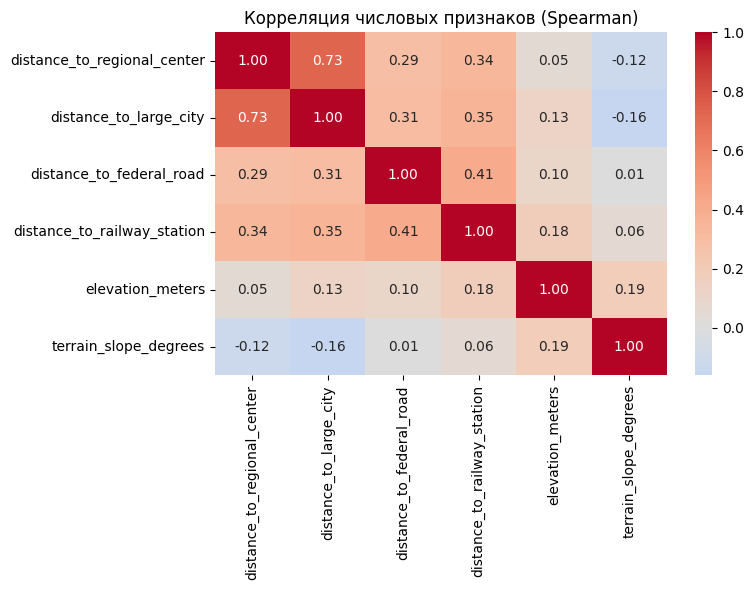

In [8]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import spearmanr
import warnings
warnings.filterwarnings('ignore')

input_file = "data_extended/9.csv"
df = pd.read_csv(input_file)


features = {
    "numeric": [
        "distance_to_regional_center",
        "distance_to_large_city",
        "distance_to_federal_road",
        "distance_to_railway_station",
        "elevation_meters",
        "terrain_slope_degrees"
    ],
    "ordinal": ["climate_severity_index"],
    "binary": ["river_barrier_flag"]
}

for key in features:
    features[key] = [f for f in features[key] if f in df.columns]

for col in sum(features.values(), []):
    missing = df[col].isna().sum()
    unique = df[col].nunique()
    dtype = df[col].dtype

    if col in features["numeric"]:
        stats = f"min={df[col].min():.1f}, max={df[col].max():.1f}, median={df[col].median():.1f}"
    elif col in features["ordinal"]:
        stats = f"values={sorted(df[col].dropna().unique())}"
    else:  # binary
        stats = f"distribution={df[col].value_counts().to_dict()}"

    print(f"{col:35s} {stats}")


if len(features["numeric"]) >= 2:
    num_df = df[features["numeric"]].dropna()

    corr = num_df.corr(method='spearman')

    plt.figure(figsize=(8, 6))
    sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
    plt.title("Корреляция числовых признаков (Spearman)")
    plt.tight_layout()
    plt.savefig("feature_correlation.png", dpi=150)

print("\nСВЯЗЬ КАТЕГОРИАЛЬНЫХ ПРИЗНАКОВ С ЧИСЛОВЫМИ")
print("=" * 60)

for cat_col in features["ordinal"] + features["binary"]:
    if cat_col not in df.columns:
        continue
    print(f"\n{cat_col}:")
    for num_col in features["numeric"]:
        if num_col not in df.columns:
            continue
        mask = df[[cat_col, num_col]].notna().all(axis=1)
        if mask.sum() > 10:
            rho, p = spearmanr(df.loc[mask, cat_col], df.loc[mask, num_col])
            sig = "+" if p < 0.05 else " "
            print(f"   {sig} {num_col:30s}: ρ = {rho:6.3f} (p={p:.3f})")